In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
ENV_NAME = 'cheetah' # cheetah | walker

In [3]:
BENCHMARK_SET = [0, 1, 2, 3]

NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

KEEP_ONLY_COORDS = False

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
from dm_control import suite

if ENV_NAME == 'cheetah':
    STATE_DIM = 17
    ACTION_DIM = 6
    # AUX_DIM = 1
    env = suite.load(
        domain_name='cheetah',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/cheetah_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_cheetah.npy')
    angmomentum_aux = np.load('datasets/angmomentum_aux_cheetah.npy')
    aux = np.concatenate((
        aux.reshape(10000, 1000, 1),
        angmomentum_aux.reshape(10000, 1000, 1)
    ), axis=-1)
    # dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 1)), axis=-1)
    
else:
    STATE_DIM = 24
    ACTION_DIM = 6
    # AUX_DIM = 3
    env = suite.load(
        domain_name='walker',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_walker.npy')
    angmomentum_aux = np.load('datasets/angmomentum_aux_walker.npy')
    aux = np.concatenate((
        aux.reshape(10000, 1000, 3),
        angmomentum_aux.reshape(10000, 1000, 1)
    ), axis=-1)
    # dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 3)), axis=-1)

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


In [5]:
dataset_trajectories = torch.tensor(dataset['observations']).float()
dataset_trajectories = dataset_trajectories
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions']).float()
dataset_terminals = torch.tensor(dataset['terminals']).float()
dataset_timeouts = torch.zeros(NUM_TRAJECTORIES, TRAJECTORY_LEN).bool()
dataset_timeouts[:, -1] = True

dataset_goals = torch.tensor(dataset['infos/goal']).float()



dataset_trajectories = dataset_trajectories.reshape(-1, TRAJECTORY_LEN, STATE_DIM)
dataset_actions = dataset_actions.reshape(-1, TRAJECTORY_LEN, ACTION_DIM)
dataset_terminals = dataset_terminals
dataset_timeouts = dataset_timeouts.reshape(-1, TRAJECTORY_LEN)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_):
    return dataset_

def denormalize_dataset_coords(dataset_):
    return dataset_

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [7]:
class VelocityRewardFunctionCheetah:
    def __init__(self):
        pass    
    
    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
        else:
            raise NotImplementedError
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='linear', value_at_margin=0):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return value
    
    def compute_reward(self, states, params):
        
        if params != 'flip':
            if isinstance(params, int):
                params = torch.full((*states.shape[:-1], 1), fill_value=params)
            
            assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

            horizontal_velocity = states[..., [0]]
            sign_of_param = np.sign(params)
            horizontal_velocity = horizontal_velocity * sign_of_param
            rew = self.tolerance(horizontal_velocity,
                                lower=np.abs(params),
                                upper=float('inf'),
                                margin=np.abs(params),
                                value_at_margin=0,
                                sigmoid='linear')
            
        else: # Flip
            _SPIN_SPEED = 5
            angmomentum = states[..., [1]]
            rew = self.tolerance(angmomentum,
                                lower=_SPIN_SPEED,
                                upper=float('inf'),
                                margin=_SPIN_SPEED,
                                value_at_margin=0,
                                sigmoid='linear')

        return torch.tensor(rew[..., 0], dtype=torch.float32)
    
    
    

class VelocityRewardFunctionWalker:
    def __init__(self):
        pass    

    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'gaussian':
            scale = np.sqrt(-2 * np.log(value_at_1))
            return np.exp(-0.5 * (x*scale)**2)

        elif sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='gaussian', value_at_margin=0.1):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return torch.tensor(value)
    
    def compute_reward(self, states, params):
        
        if params != 'flip':
            if isinstance(params, int) or isinstance(params, float):
                params = torch.full((*states.shape[:-1], 1), fill_value=params)
            
            assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

            _STAND_HEIGHT = 1.2
            horizontal_velocity = states[..., [0]]
            torso_upright = states[..., [1]]
            torso_height = states[..., [2]]
            standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
            upright = (1 + torso_upright) / 2
            stand_reward = (3*standing + upright) / 4
            move_reward = self.tolerance(horizontal_velocity,
                                            lower=params,
                                            upper=float('inf'),
                                            margin=params/2,
                                            value_at_margin=0.5,
                                            sigmoid='linear')
            # move_reward[params == 0] = stand_reward[params == 0]
            
        
        else: # flip
            _STAND_HEIGHT = 1.2
            _SPIN_SPEED = 5
            horizontal_velocity = states[..., [0]]
            torso_upright = states[..., [1]]
            torso_height = states[..., [2]]
            angmomentum = states[..., [3]]
            standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
            upright = (1 + torso_upright) / 2
            stand_reward = (3*standing + upright) / 4
            move_reward = self.tolerance(angmomentum,
                                            lower=_SPIN_SPEED,
                                            upper=float('inf'),
                                            margin=_SPIN_SPEED,
                                            value_at_margin=0.5,
                                            sigmoid='linear')
            # move_reward[params == 0] = stand_reward[params == 0]
        
        rew = stand_reward * (5*move_reward + 1) / 6    
                
        return torch.tensor(rew[..., 0], dtype=torch.float32)
    
    
    
    
if ENV_NAME == 'cheetah':
    velocity_reward_function = VelocityRewardFunctionCheetah()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel10Back', -10),
        (velocity_reward_function.compute_reward, 'vel2Back', -2),
        (velocity_reward_function.compute_reward, 'vel2', 2),
        (velocity_reward_function.compute_reward, 'vel10', 10),
        (velocity_reward_function.compute_reward, 'flip', 'flip'),
    ]
else:
    velocity_reward_function = VelocityRewardFunctionWalker()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel0.1', 0.1),
        (velocity_reward_function.compute_reward, 'vel1', 1),
        (velocity_reward_function.compute_reward, 'vel4', 4),
        (velocity_reward_function.compute_reward, 'vel8', 8),
        (velocity_reward_function.compute_reward, 'flip', 'flip'),
    ]

In [8]:
BD_SIZE = 1000
SUBTRAJECTORY_SIZE = 100
SUBTRAJECTORY_SKIP = 10

In [9]:
# x = dataset_trajectories_cuda[::10, ::10].reshape(1, -1, STATE_DIM)
# x_physics = dataset_trajectories_cuda[::10, ::10].reshape(1, -1, STATE_DIM)

x = []
x_physics = []
x_aux = []
for _ in range(BD_SIZE):
    i = random.randint(0, 10000-1)
    j = random.randint(0,  1000-SUBTRAJECTORY_SIZE*SUBTRAJECTORY_SKIP)
    x.append(dataset_trajectories_cuda[i, j:j+SUBTRAJECTORY_SIZE*SUBTRAJECTORY_SKIP:SUBTRAJECTORY_SKIP])
    x_physics.append(dataset['physics'][i, j:j+SUBTRAJECTORY_SIZE*SUBTRAJECTORY_SKIP:SUBTRAJECTORY_SKIP])
    x_aux.append(aux[i, j:j+SUBTRAJECTORY_SIZE*SUBTRAJECTORY_SKIP:SUBTRAJECTORY_SKIP])
    
x = torch.stack(x).reshape(1, -1, STATE_DIM)
x_aux = torch.tensor(np.stack(x_aux))
x_physics = torch.tensor(np.stack(x_physics)).reshape(BD_SIZE, SUBTRAJECTORY_SIZE, -1)

In [10]:
class MiniMLPs(nn.Module):
    def __init__(self, N):
        super(MiniMLPs, self).__init__()
        self.N = N
        self.C = 0
        self.mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(STATE_DIM, 32),
                nn.Sigmoid(),
                nn.Linear(32, 32),
                nn.Sigmoid(),
                nn.Linear(32, 1),
                # nn.Tanh()
            )
            for i in range(N)
        ])

    def forward(self, x, ids=None):
        rewards = []
        with torch.no_grad():

            if ids is None:
                ids = list(range(len(self.mlps)))
            
            for i in ids:
                r = self.mlps[i](x)
                rewards.append(r)
        
        rewards = torch.concat(rewards)
        
        rewards = rewards / (1+rewards.abs())
        
        return rewards

---

In [11]:
def correlation_matrix(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """
    Compute correlation matrix between rows of A (N, dim) and B (M, dim).
    Returns (N, M).
    """
    assert A.dim() == 2 and B.dim() == 2
    assert A.size(1) == B.size(1), "Last dimension must match"

    # Center the rows
    A_centered = A - A.mean(dim=1, keepdim=True)
    B_centered = B - B.mean(dim=1, keepdim=True)

    # Normalize to unit variance
    A_norm = A_centered / (A_centered.norm(dim=1, keepdim=True) + 1e-8)
    B_norm = B_centered / (B_centered.norm(dim=1, keepdim=True) + 1e-8)

    # Correlation = cosine similarity after mean-centering
    corr = A_norm @ B_norm.T
    return corr

In [12]:
import torch

def kendall_tau_matrix(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """
    Compute Kendall's tau correlation matrix between rows of A and rows of B.
    
    A: (N, M) tensor
    B: (K, M) tensor
    Returns: (N, K) tensor with Kendall's tau values
    """
    N, M = A.shape
    K = B.shape[0]
    result = torch.empty((N, K), dtype=torch.float32, device=A.device)

    # Upper triangular mask to avoid duplicate pairs within a row
    mask = torch.triu(torch.ones(M, M, dtype=bool, device=A.device), 1)

    for i in range(N):
        xi = A[i]
        diff_x = xi.unsqueeze(0) - xi.unsqueeze(1)
        sign_x = torch.sign(diff_x[mask])

        for j in range(K):
            yj = B[j]
            diff_y = yj.unsqueeze(0) - yj.unsqueeze(1)
            sign_y = torch.sign(diff_y[mask])

            concordant = (sign_x * sign_y > 0).sum()
            discordant = (sign_x * sign_y < 0).sum()

            tau = (concordant - discordant).float() / (concordant + discordant).float()
            result[i, j] = tau

    return result




import torch

def kendall_signature(X: torch.Tensor):
    """
    Convert rows of X into Kendall sign signatures.
    Each row of X -> vector of signs for all pairwise differences.
    """
    N, M = X.shape
    idx_i, idx_j = torch.triu_indices(M, M, offset=1)
    diffs = X[:, idx_i] - X[:, idx_j]  # (N, P)
    return torch.sign(diffs)  # concordant=+1, discordant=-1, tie=0

def kendall_tau_matrix_2(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """
    Compute Kendall's tau-b correlation matrix between rows of A and B.
    A: (N, M)
    B: (K, M)
    Returns: (N, K)
    """
    sigA = kendall_signature(A)   # (N, P)
    sigB = kendall_signature(B)   # (K, P)
    P = sigA.shape[1]

    dot = sigA @ sigB.T  # (N, K), numerator (C - D)

    # Effective pair counts per row (ignoring ties)
    countA = sigA.abs().sum(dim=1, keepdim=True)  # (N, 1)
    countB = sigB.abs().sum(dim=1, keepdim=True)  # (K, 1)

    denom = torch.sqrt(countA @ countB.T).clamp(min=1.0)

    return dot / denom


In [13]:
def jaccard_similarity_matrix(A, B):
    """
    A: LongTensor of shape (N, dim) containing IDs
    B: LongTensor of shape (M, dim) containing IDs
    Returns: FloatTensor of shape (N, M) with Jaccard similarity
    """
    N, dim_A = A.shape
    M, dim_B = B.shape
    
    # Ensure no duplicates per row
    A_unique = [set(row.tolist()) for row in A]
    B_unique = [set(row.tolist()) for row in B]
    
    # Preallocate similarity matrix
    sim_matrix = torch.zeros((N, M), dtype=torch.float32)
    
    for i, a_row in enumerate(A_unique):
        for j, b_row in enumerate(B_unique):
            intersection = len(a_row.intersection(b_row))
            union = len(a_row.union(b_row))
            sim_matrix[i, j] = intersection / union if union > 0 else 0.0
    
    return sim_matrix

In [14]:

# A = torch.tensor([
#     [1, 2, 3],
#     [4, 5, 6]
# ])
# B = torch.tensor([
#     [3, 2, 7],
#     [5, 6, 8],
#     [1, 9, 3]
# ])

def jaccard_similarity_matrix_2(A, B):

    # Shapes
    N, dim = A.shape
    M, _ = B.shape

    # Expand A and B for broadcasting: (N, 1, dim) vs (1, M, dim)
    A_exp = A.unsqueeze(1)           # (N, 1, dim)
    B_exp = B.unsqueeze(0)           # (1, M, dim)

    # Compare pairwise equality across dim
    # Result: (N, M, dim) boolean tensor
    eq = (A_exp.unsqueeze(-1) == B_exp.unsqueeze(-2))  # (N, M, dim, dim)

    # Count matches: reduce last two axes
    inter_counts = eq.any(-1).sum(-1)
    union_counts = 2*dim - inter_counts

    return inter_counts / union_counts

In [15]:
def update_container(container_mlps, container_bds, container_fs, threshold=0.5, K=10, max_C=50):
    
    
    sort_values, sort_indices = container_fs.sort(descending=True)

    new_container_mlps_list = []
    new_container_bds = torch.zeros_like(container_bds)
    new_container_fs = torch.zeros_like(container_fs)
    
    y2 = torch.zeros((container_bds.shape[0], K), dtype=torch.float32, device=device)
    
    NEW_C = 0
    for i in sort_indices:
        
        
        if NEW_C == max_C:
            break
        
        if len(new_container_mlps_list) == 0:
            new_container_mlps_list.append(
                [(container_mlps.mlps[i][l].weight.data, container_mlps.mlps[i][l].bias.data) for l in [0, 2, 4]]
            )
            new_container_bds[NEW_C] = container_bds[i]
            new_container_fs[NEW_C] = container_fs[i]
            y2[NEW_C] = new_container_bds[NEW_C].argsort(dim=-1).float()[-K:]
            NEW_C += 1
            
            
        else: # Contrainer already has some solutions
            # distances = (container_bds[i] - new_container_bds[:NEW_C]).norm(dim=-1, p=2)
            # distances = correlation_matrix(container_bds[i].unsqueeze(0), new_container_bds)
            y1 = container_bds[i].unsqueeze(0).argsort(dim=-1)[:, -K:].float()
            distances = jaccard_similarity_matrix_2(y1, y2)
            
            if distances.sort(descending=True).values[0, 0] < threshold:
                new_container_mlps_list.append(
                    [(container_mlps.mlps[i][l].weight.data, container_mlps.mlps[i][l].bias.data) for l in [0, 2, 4]]
                )
                new_container_bds[NEW_C] = container_bds[i]
                new_container_fs[NEW_C] = container_fs[i]
                y2[NEW_C] = new_container_bds[NEW_C].argsort(dim=-1).float()[-K:]
                NEW_C += 1
                
            
            
    container_mlps.C = NEW_C

    for i in range(len(new_container_mlps_list)):
        for l_i, l in enumerate([0, 2, 4]):
            container_mlps.mlps[i][l].weight.data = new_container_mlps_list[i][l_i][0]
            container_mlps.mlps[i][l].bias.data = new_container_mlps_list[i][l_i][1]
        # print(torch.stack([container_mlps.mlps[i][0].bias.data[0] for i in range(container_mlps.C)]))
            
    return container_mlps, new_container_bds[:NEW_C], new_container_fs[:NEW_C]

In [16]:
def prune_tensor(x: torch.Tensor, p: float) -> torch.Tensor:
    mask = torch.bernoulli(torch.full_like(x, 1 - p))
    return x * mask

In [17]:
N_children = 4
lr = 0.05


batch_size = 32
k_neighbors = 10


In [18]:
container_mlps = MiniMLPs(N=500).to(device)
children_mlps = MiniMLPs(N=500).to(device)


scores = []
expressivities = []

container_bds = torch.zeros((0, 2), dtype=torch.float32)
container_fs = torch.zeros((0,), dtype=torch.float32)

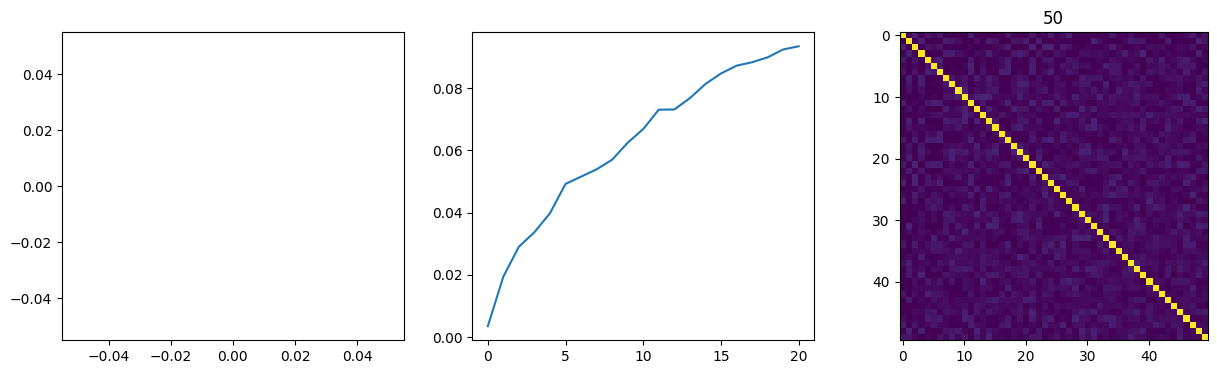

  0%|          | 25/100000 [00:02<3:15:01,  8.54it/s]


KeyboardInterrupt: 

In [19]:
for step in tqdm(range(100000)):
    
    
    C = len(container_bds)  
    
    if C == 0:
        parents_ids = list(range(batch_size))
        children_ids = list(range(batch_size*N_children))
    else:
        parents_ids = [random.randint(0, C-1) for _ in range(batch_size)]
        children_ids = list(range(batch_size*N_children))
        for i, parent_id in enumerate(parents_ids):
            for j in range(N_children):
                for l in [0, 2, 4]:
                    lr = random.choice([1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1])
                    children_mlps.mlps[i*N_children + j][l].weight.data = container_mlps.mlps[parent_id][l].weight.data + torch.normal(0, lr, container_mlps.mlps[parent_id][l].weight.shape, device=device)
                    children_mlps.mlps[i*N_children + j][l].bias.data   = container_mlps.mlps[parent_id][l].bias.data   + torch.normal(0, lr, container_mlps.mlps[parent_id][l].bias.shape, device=device)
                    # if l == 0:
                    #     children_mlps.mlps[i*N_children + j][l].weight.data = prune_tensor(children_mlps.mlps[i*N_children + j][l].weight.data, 0.5)
                    #     children_mlps.mlps[i*N_children + j][l].bias.data   = torch.zeros_like(children_mlps.mlps[i*N_children + j][l].bias.data)
    
    # Evaluation of individuals in offspring population:
    r = children_mlps(x, children_ids)
    r = r.reshape(-1, BD_SIZE, SUBTRAJECTORY_SIZE)
    
    children_bds = r.mean(dim=-1)      
    
    signal = r.mean(dim=-1).std(dim=-1)
    # signal = torch.clip(signal, max=0.5)
    noise = r.std(dim=-1).mean(dim=-1)
    noise = torch.ones_like(noise)
    expressivity = signal / (noise + 1e-9)
    # expressivity = torch.clip(expressivity, min=0, max=0.5)
    # expressivity = torch.ones_like(expressivity)
    # expressivity = 1 / (noise + 1e-9)
    
    
    # expressivity = dataset_trajectories_cuda[
    #     children_bds.argsort(dim=-1)[:, -10:].flatten().cpu(),
    #     :, 17
    # ].to(device).mean(dim=-1).reshape(N_children*batch_size, 10).mean(dim=-1)
    # expressivity = torch.ones((N_children*batch_size,), dtype=torch.float32)
    
    
    # Try to update the container:
    
    if len(container_bds) == 0:
        container_bds = children_bds[[0]]
        container_fs = expressivity[[0]]
        
        children_ids = children_ids[:-1]
        children_bds = children_bds[1:]
        expressivity = expressivity[1:]
        
    
    


    # Check the children to be added to the container:

    # break
    
    for child_id in children_ids:
        
        
        # distances = (children_bds.unsqueeze(1) - container_bds.unsqueeze(0)).norm(dim=-1, p=2)
        # distances = correlation_matrix(children_bds, container_bds)
        # sort_values, sort_indices = distances.sort(descending=True)

        # k_nearest_distance_to_child = sort_values[child_id, :k_neighbors].mean(dim=-1)
        # nearest_id_to_child = sort_indices[child_id, 0]
        

        # if k_nearest_distance_to_child > 0.8: # Either replace an existing solution or be thrown away
            
        #     # pass
            
        #     archive_id_to_replace = nearest_id_to_child
            
        #     # print(expressivity[child_id], container_fs[archive_id_to_replace])
        #     if expressivity[child_id] > container_fs[archive_id_to_replace] * 1:                
                
        #         for l in [0, 2, 4]:
        #             container_mlps.mlps[archive_id_to_replace][l].weight.data = children_mlps.mlps[child_id][l].weight.data

        #         # print(container_bds[archive_id_to_replace])
        #         container_bds[archive_id_to_replace] = children_bds[child_id]
        #         container_fs[archive_id_to_replace] = expressivity[child_id]
        #         # print(container_bds[archive_id_to_replace])
        #         # print(child_id, '->', archive_id_to_replace)

                

        # elif container_mlps.C < container_mlps.N-1: # The child is novel, so we add it to the container
                    
        if container_mlps.C < container_mlps.N-1:       
            C = container_mlps.C
            for l in [0, 2, 4]:
                container_mlps.mlps[C][l].weight.data = children_mlps.mlps[child_id][l].weight.data
                container_mlps.mlps[C][l].bias.data   = children_mlps.mlps[child_id][l].bias.data
            container_mlps.C += 1
                    
            container_bds = torch.concat((container_bds, children_bds[child_id].unsqueeze(0)))
            container_fs = torch.concat((container_fs, expressivity[child_id].unsqueeze(0)))
            
            
            


    
    # scores.append(score[top_population_idx].mean().item())
    
    
    # break
    # print(container_bds.shape)
    
    container_mlps, container_bds, container_fs = update_container(container_mlps, container_bds, container_fs, threshold=0.1, K=50, max_C=50)
    
    # continue
    
    expressivities.append(container_fs.mean().item())
    
    # print(container_bds.shape)
    
    
    # break
        
    if step % 20 == 0:
        clear_output(True)
        # print(container_mlps.C)
        
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        axs[0].plot(scores)
        
        # _ = axs[2].hist(bd[0].cpu(), bins=100) 
        # axs[2].imshow(row_cross_correlation(bd).cpu(), vmin=-1, vmax=1)
        # axs[1].set_xlim([-1, 1]) 
        
        axs[1].plot(expressivities)
        # axs[1].set_ylim([0, 1]) 
                
        # axs[2].imshow(correlation_matrix(container_bds, container_bds).cpu(), vmin=-1, vmax=1)
        y = container_bds.argsort(dim=-1).float()[:, -50:]
        axs[2].imshow(jaccard_similarity_matrix_2(y, y).cpu(), vmin=0, vmax=1)
        axs[2].set_title(f'{len(container_bds)}')
        
        plt.show()  
     
    # break

In [396]:
# r = container_mlps(x, list(range(200)))
# r = r.reshape(-1, BD_SIZE, SUBTRAJECTORY_SIZE)

# bds = r.mean(dim=-1)

# _ = plt.hist(bds.argsort(dim=-1)[:, -1].cpu(), bins=1000)

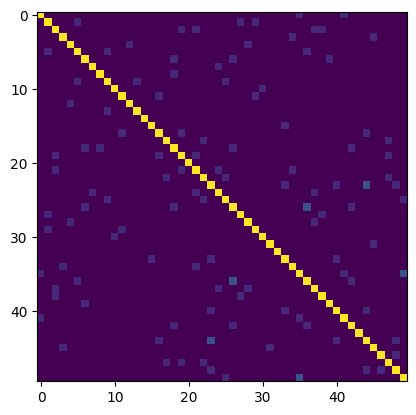

In [302]:
y = container_bds.argsort(dim=-1).float()[:, -5:]
plt.imshow(jaccard_similarity_matrix(y, y), vmin=0, vmax=1)

(array([45., 79.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  2.]),
 array([0.06579877, 0.09933757, 0.13287637, 0.16641515, 0.19995394,
        0.23349273, 0.26703152, 0.30057034, 0.33410913, 0.36764792,
        0.4011867 ]),
 <BarContainer object of 10 artists>)

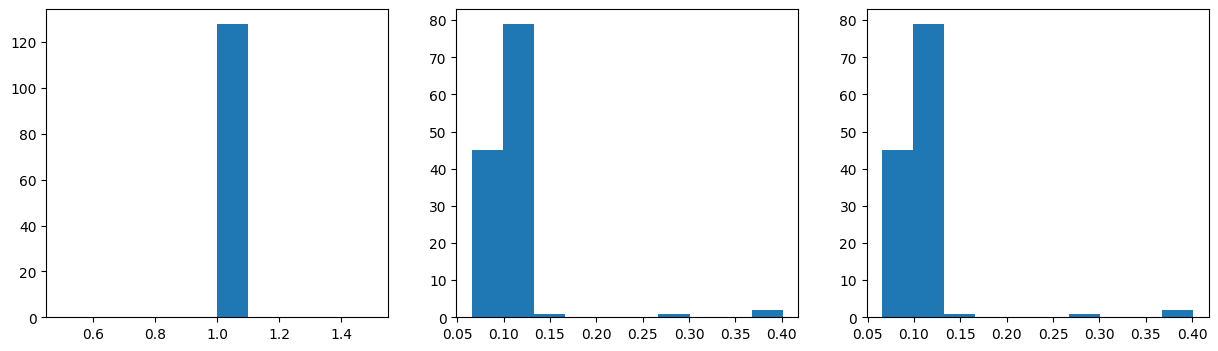

In [303]:
fig, axs  = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(noise.flatten().cpu())
axs[1].hist(signal.flatten().cpu())
axs[2].hist(expressivity.flatten().cpu())

(-1.0, 1.0)

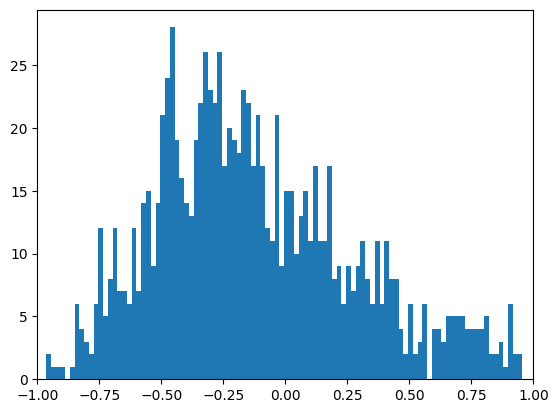

In [304]:
_ = plt.hist(container_bds[0].cpu(), bins=100)
plt.xlim([-1, 1])

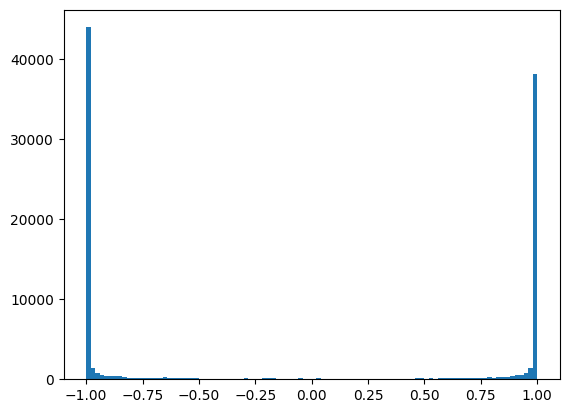

In [305]:
_ = plt.hist(r[4].flatten().cpu(), bins=100)
# plt.xlim([-1, 1])

In [306]:
ma_ = -10000
for i in range(len(container_bds)):
    ids = container_bds[i].argsort()[-50:].cpu() * 10
    f = dataset['physics'][ids, -1, 0].mean()
    if f > ma_:
        print(i, f)
        ma_ = f
    # break

0 -0.4838095011107111
1 -0.4656602649164998
7 -0.43984174491980704
36 -0.43499256780219797


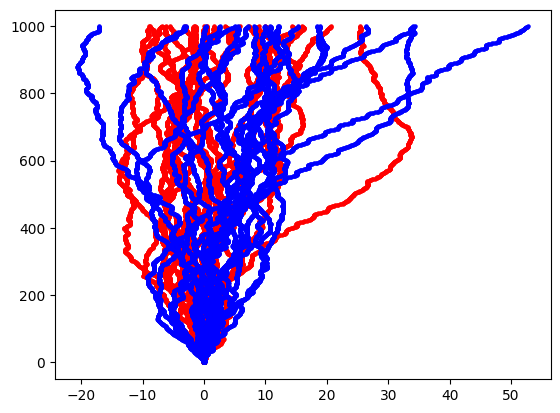

In [354]:
y = dataset_trajectories_cuda[::10, ::10]

# model = nn.Sequential(
#     nn.Linear(1, 32),
#     nn.ReLU(),
#     nn.Linear(32, 32),
#     nn.ReLU(),
#     nn.Linear(32, 1),
# ).to(device)

# r = model(y[..., [0]])
# r = r.reshape(-1, 1000, 100)
# bds = r.mean(dim=-1)  


i = 39
# r = container_mlps(y, list(range(container_mlps.C)))
r = container_mlps(y)
bds = r.reshape(-1, 1000, 100).mean(dim=-1)

# i = 0; bds = r_.reshape(1, 1000, 100).mean(dim=-1)


ids = bds[i].argsort()[:20].cpu()*10
plt.scatter(
    dataset['physics'][ids, :, 1],
    torch.arange(1000).reshape(1, -1).repeat(20, 1),
    c='red', s=5
)


ids = bds[i].argsort()[-20:].cpu()*10
plt.scatter(
    dataset['physics'][ids, :, 1],
    torch.arange(1000).reshape(1, -1).repeat(20, 1),
    c='blue', s=5
)

# plt.xlim([-30, 30])

In [147]:
r_reshaped = r.reshape(-1, 1000, 100)

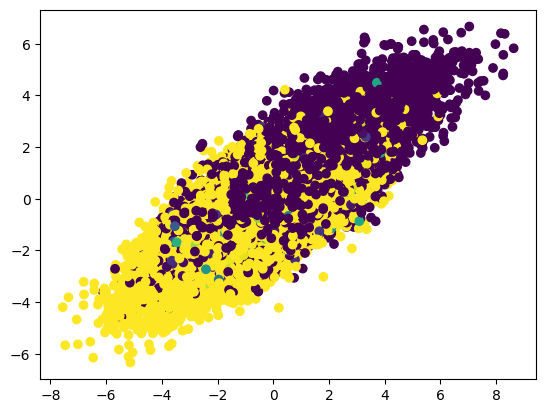

In [150]:
i = 50

ri = r_reshaped[i].flatten()
r_sort_idx = ri.sort().indices.cpu()
# x8 = y[..., 8].flatten()[r_sort_idx].cpu()
# x8 = y[..., 16].flatten()[r_sort_idx].cpu()
# x0 = aux[::10, ::10, 0].flatten()[r_sort_idx]
# ri = ri[r_sort_idx].cpu()

x8 = y[..., 8].flatten().cpu()
x0 = aux[::10, ::10, 0].flatten()
ri = ri.cpu()

plt.scatter(x8, x0, c=ri)

In [335]:
# plt.scatter(y[..., 8].cpu(), y[..., 0].cpu(), c=r.reshape(-1, 1000, 100)[0].cpu())

i = 4
plt.scatter(y[..., 16].cpu(), aux[::10, ::10, 2], c=r_reshaped[i].cpu())

IndexError: index 2 is out of bounds for axis 2 with size 2

/tmp/ipykernel_49166/2465053242.py:116: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(rew[..., 0], dtype=torch.float32)


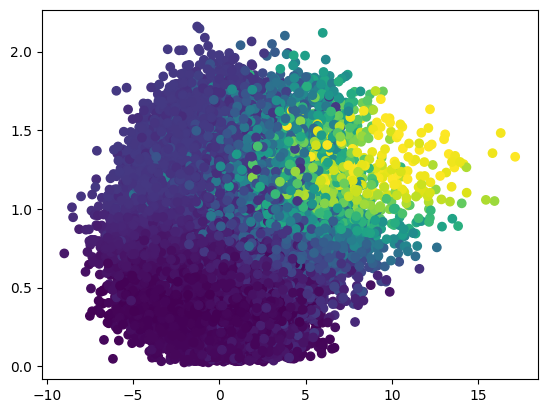

In [259]:
benchmark_id = 2
benchmark_reward_function, _, benchmark_param = benchmarks[benchmark_id]
r_ = benchmark_reward_function(
    torch.tensor(aux[::10, ::10]),
    benchmark_param
)
plt.scatter(dataset_trajectories[::10, ::10, 16], aux[::10, ::10, 2], c=r_)
# plt.scatter(dataset_trajectories[::10, ::10, 2], dataset_trajectories[::10, ::10, 4], c=r_)